In [38]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd

# Replace with your Spotify Developer credentials
CLIENT_ID = "fd124bbba4574b8599bf93a2d004a426"
CLIENT_SECRET = "b7a03b5759c24c56986deb2b4aad3d2f"

auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth_manager)


In [39]:
indian_playlists = {
    "Top Hits India": "37i9dQZF1DX0XUfTFmNBRM",
    "Bollywood Butter": "37i9dQZF1DX1wFVBjmQoez",
    "Indie India": "37i9dQZF1DWXVJK4aT7pmk",
    "Punjabi 101": "37i9dQZF1DX0XUsuxWHRQd",
    "Tollywood Pearls": "37i9dQZF1DX2WkIBRaChxW"
}


In [40]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import os
from dotenv import load_dotenv

# 1. Try to load from .env file
load_dotenv()

CLIENT_ID = os.getenv("CLIENT_ID")
CLIENT_SECRET = os.getenv("CLIENT_SECRET")

# 2. If not found, set them directly here (fallback)
if not CLIENT_ID or not CLIENT_SECRET:
   CLIENT_ID = "fd124bbba4574b8599bf93a2d004a426"
   CLIENT_SECRET = "b7a03b5759c24c56986deb2b4aad3d2f"

# 3. Authenticate with Spotify
auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth_manager)

print("✅ Spotify authentication successful!")


✅ Spotify authentication successful!


In [41]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

CLIENT_ID = "fd124bbba4574b8599bf93a2d004a426"
CLIENT_SECRET = "b7a03b5759c24c56986deb2b4aad3d2f"

auth_manager = SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET)
sp = spotipy.Spotify(auth_manager=auth_manager)

print("✅ Spotify authentication success")


✅ Spotify authentication success


In [42]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import pandas as pd
import time
from requests.exceptions import SSLError
from spotipy.exceptions import SpotifyException
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -----------------------------
# Spotify client setup
# -----------------------------
sp = spotipy.Spotify(
    client_credentials_manager=SpotifyClientCredentials(
        client_id="fd124bbba4574b8599bf93a2d004a426",
        client_secret="b7a03b5759c24c56986deb2b4aad3d2f"
    ),
    requests_timeout=30
)

# -----------------------------
# Playlists dictionary
# -----------------------------
indian_playlists = {
    "Bollywood Top 50": "0i2S0eEdftTrmLKueMWUKX",
    "Punjabi Hits": "4fzks84g3qzZVItBLBcG8H",
    # "Tamil Hot Hits": "37i9dQZF1DX1i3hvzHpcQV",   # old/invalid
    # "Telugu Hot Hits": "37i9dQZF1DWTt3gMo0DLxA"
    "Indie India": "37i9dQZF1DWXVJK4aT7pmk",
    "Tollywood Pearls": "37i9dQZF1DX2WkIBRaChxW"

}

# -----------------------------
# Helper: safe request with retries
# -----------------------------
def safe_request(func, *args, **kwargs):
    retries = 5
    for i in range(retries):
        try:
            return func(*args, **kwargs)
        except (SSLError, SpotifyException) as e:
            wait = 2 ** i
            print(f"Error: {e}. Retrying {i+1}/{retries} in {wait}s...")
            time.sleep(wait)
    raise Exception("Max retries exceeded for Spotify request")

# -----------------------------
# Fetch all tracks from playlist
# -----------------------------
def get_all_tracks(playlist_id, market="IN"):
    tracks = []
    offset = 0
    while True:
        results = safe_request(sp.playlist_items, playlist_id, limit=50, offset=offset, market=market)
        tracks.extend(results['items'])
        if results['next'] is None:
            break
        offset += 50
    return tracks

# -----------------------------
# Load existing data if available
# -----------------------------
if os.path.exists("indian_tracks.csv"):
    df = pd.read_csv("indian_tracks.csv")
    processed_playlists = set(df['playlist'].unique())
    print("Resuming from saved data...")
else:
    df = pd.DataFrame()
    processed_playlists = set()

# -----------------------------
# Fetch tracks and audio features
# -----------------------------
for playlist_name, playlist_id in indian_playlists.items():
    if playlist_name in processed_playlists:
        print(f"Skipping already processed playlist: {playlist_name}")
        continue

    print(f"Fetching: {playlist_name}")
    items = get_all_tracks(playlist_id)

    track_ids = []
    tracks_data = []

    for item in items:
        track = item['track']
        if track and track['id']:
            tracks_data.append({
                "playlist": playlist_name,
                "track_name": track['name'],
                "artist": ", ".join([a['name'] for a in track['artists']]),
                "album": track['album']['name'],
                "release_date": track['album']['release_date'],
                "popularity": track['popularity'],
                "track_id": track['id']
            })
            track_ids.append(track['id'])

    # Fetch audio features in batches of 100
    features = []
    for i in range(0, len(track_ids), 100):
        batch = track_ids[i:i+100]
        try:
            features.extend(safe_request(sp.audio_features, batch))
        except Exception as e:
            print(f"Failed fetching audio features for batch: {e}")
            continue

    # Map features by track ID
    features_dict = {f['id']: f for f in features if f}

    # Add audio features safely
    for track in tracks_data:
        feat = features_dict.get(track['track_id'])
        if feat:
            track.update({
                "danceability": feat['danceability'],
                "energy": feat['energy'],
                "tempo": feat['tempo'],
                "valence": feat['valence'],
                "acousticness": feat['acousticness'],
                "instrumentalness": feat['instrumentalness']
            })

    # Append to main DataFrame and save after each playlist
    df = pd.concat([df, pd.DataFrame(tracks_data)], ignore_index=True)
    df.to_csv("indian_tracks.csv", index=False)
    print(f"✅ Saved {len(tracks_data)} tracks for playlist '{playlist_name}'")

# -----------------------------
# Check columns before plotting
# -----------------------------
print("Available columns:", df.columns)
print(df.head())

# -----------------------------
# Plotting
# -----------------------------
if "popularity" in df.columns:
    plt.figure(figsize=(8,6))
    sns.histplot(df['popularity'], bins=20, kde=True)
    plt.title("Popularity Distribution of Indian Songs")
    plt.show()

if "energy" in df.columns and "valence" in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='energy', y='valence', hue='playlist', data=df)
    plt.title("Energy vs Valence (Mood) of Indian Songs")
    plt.show()
else:
    print("⚠️ Missing 'energy' or 'valence' columns, skipping scatter plot.")


Resuming from saved data...
Skipping already processed playlist: Bollywood Top 50
Skipping already processed playlist: Punjabi Hits
Fetching: Indie India


HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': 'IN', 'additional_types': 'track,episode'} returned 404 due to Resource not found


Error: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks?limit=50&offset=0&market=IN&additional_types=track%2Cepisode:
 Resource not found, reason: None. Retrying 1/5 in 1s...


HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': 'IN', 'additional_types': 'track,episode'} returned 404 due to Resource not found


Error: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks?limit=50&offset=0&market=IN&additional_types=track%2Cepisode:
 Resource not found, reason: None. Retrying 2/5 in 2s...


...

HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': 'IN', 'additional_types': 'track,episode'} returned 404 due to Resource not found


Error: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks?limit=50&offset=0&market=IN&additional_types=track%2Cepisode:
 Resource not found, reason: None. Retrying 4/5 in 8s...


HTTP Error for GET to https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks with Params: {'limit': 50, 'offset': 0, 'fields': None, 'market': 'IN', 'additional_types': 'track,episode'} returned 404 due to Resource not found


Error: http status: 404, code: -1 - https://api.spotify.com/v1/playlists/37i9dQZF1DWXVJK4aT7pmk/tracks?limit=50&offset=0&market=IN&additional_types=track%2Cepisode:
 Resource not found, reason: None. Retrying 5/5 in 16s...


Exception: Max retries exceeded for Spotify request

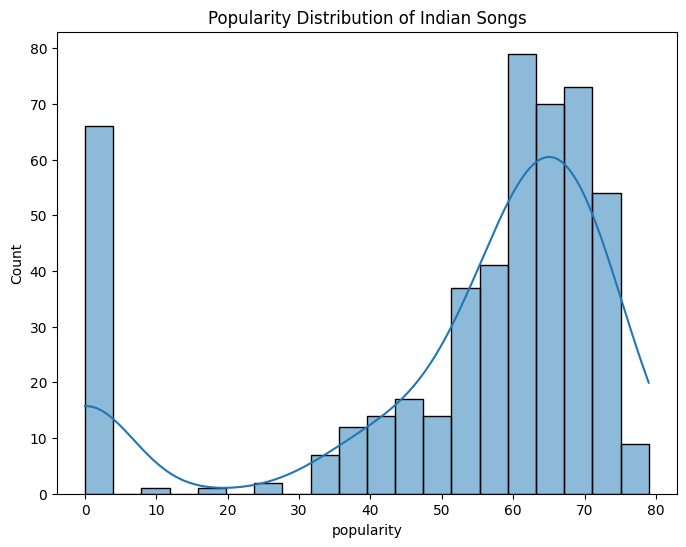

⚠️ 'energy', 'valence', or 'playlist' column is missing in df


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Popularity plot (safe) ---
if "popularity" in df.columns:
    plt.figure(figsize=(8,6))
    sns.histplot(df['popularity'], bins=20, kde=True)
    plt.title("Popularity Distribution of Indian Songs")
    plt.show()
else:
    print("⚠️ 'popularity' column is missing in df")

# --- Energy vs Valence plot (safe) ---
if {"energy", "valence", "playlist"}.issubset(df.columns):
    plt.figure(figsize=(8,6))
    sns.scatterplot(x="energy", y="valence", hue="playlist", data=df)
    plt.title("Energy vs Valence (Mood) of Indian Songs")
    plt.show()
else:
    print("⚠️ 'energy', 'valence', or 'playlist' column is missing in df")


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define expected audio feature columns
features = ["danceability", "energy", "tempo", "valence", "acousticness", "instrumentalness"]

# Check which of them actually exist in your dataframe
available_features = [col for col in features if col in df.columns]
print("✅ Using features:", available_features)

if available_features:
    # Drop rows with NaN in selected features
    X = df[available_features].dropna()

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=4, random_state=42)
    df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)

    # Plot only if 'energy' and 'valence' exist
    if {"energy", "valence"}.issubset(df.columns):
        plt.figure(figsize=(8,6))
        sns.scatterplot(
            x=df.loc[X.index, "energy"],
            y=df.loc[X.index, "valence"],
            hue=df.loc[X.index, "cluster"],
            palette="viridis"
        )
        plt.title("Clusters of Indian Songs (Energy vs Valence)")
        plt.show()
    else:
        print("⚠️ 'energy' or 'valence' missing, cannot plot scatter.")
else:
    print("⚠️ None of the expected audio feature columns are available in df.")


✅ Using features: []
⚠️ None of the expected audio feature columns are available in df.


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Binary label: popular if popularity >= 60
df['popular_label'] = (df['popularity'] >= 60).astype(int)

X = df[features].dropna()
y = df.loc[X.index, 'popular_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
